<a href="https://colab.research.google.com/github/Aditipujari10/Deep_Learning_Lab/blob/main/DL_EXP_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing import sequence

In [ ]:
# Only keep top 10,000 words
max_features = 10000
maxlen = 200  # review length

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Pad sequences (make all reviews same length)
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

print("Training shape:", x_train.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (25000, 200)


In [ ]:
def build_rnn():
    model = Sequential()
    model.add(Embedding(max_features, 128, input_length=maxlen))
    model.add(SimpleRNN(64))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

In [ ]:
def build_lstm():
    model = Sequential()
    model.add(Embedding(max_features, 128, input_length=maxlen))
    model.add(LSTM(64))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

In [ ]:
def build_gru():
    model = Sequential()
    model.add(Embedding(max_features, 128, input_length=maxlen))
    model.add(GRU(64))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

In [ ]:
epochs = 5
batch_size = 64

# Train RNN
rnn_model = build_rnn()
history_rnn = rnn_model.fit(x_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_split=0.2)

# Train LSTM
lstm_model = build_lstm()
history_lstm = lstm_model.fit(x_train, y_train,
                              epochs=epochs,
                              batch_size=batch_size,
                              validation_split=0.2)

# Train GRU
gru_model = build_gru()
history_gru = gru_model.fit(x_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_split=0.2)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 92ms/step - accuracy: 0.6448 - loss: 0.6163 - val_accuracy: 0.8190 - val_loss: 0.4161
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.8253 - loss: 0.3931 - val_accuracy: 0.8246 - val_loss: 0.4429
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.9247 - loss: 0.1975 - val_accuracy: 0.8008 - val_loss: 0.4762
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.9875 - loss: 0.0496 - val_accuracy: 0.7876 - val_loss: 0.5937
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.9951 - loss: 0.0207 - val_accuracy: 0.8094 - val_loss: 0.6609
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 236ms/step - accuracy: 0.7944 - loss: 0.4292 - val_accuracy: 0.8730 - val_loss: 0.3193
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 239ms/step - accuracy: 0.9043 - loss: 0.2423 - val_accuracy: 0.8670 - val_loss: 0.3128
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 237ms/step - accuracy: 0.9376 - loss: 0.1705 - val_accuracy: 0

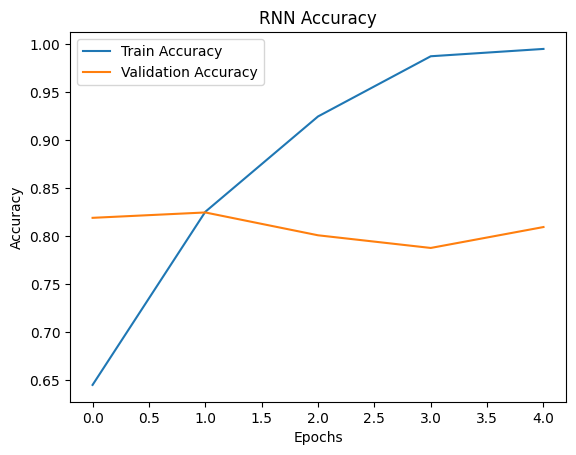

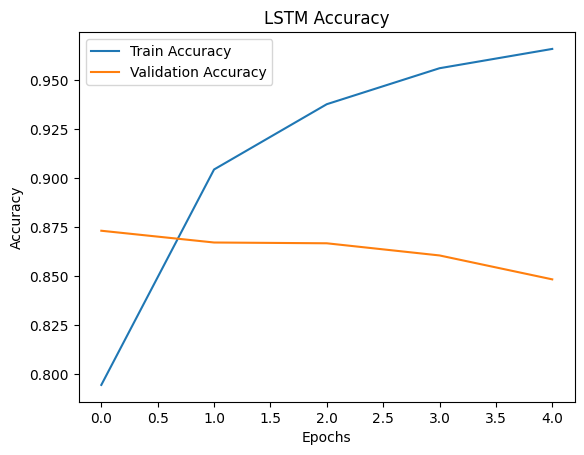

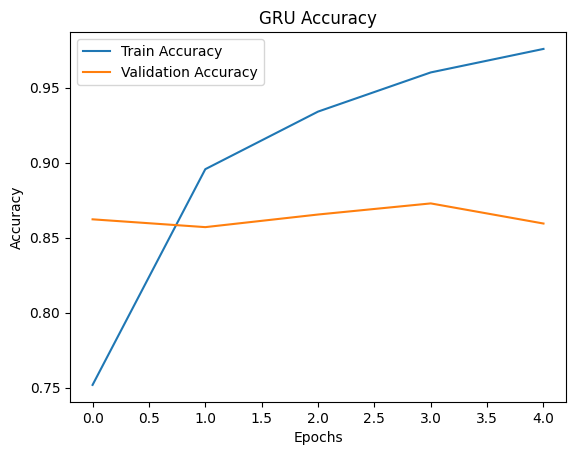

In [ ]:
print("RNN Test Accuracy:", rnn_model.evaluate(x_test, y_test)[1])
print("LSTM Test Accuracy:", lstm_model.evaluate(x_test, y_test)[1])
print("GRU Test Accuracy:", gru_model.evaluate(x_test, y_test)[1])

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8044 - loss: 0.6740
RNN Test Accuracy: 0.8043599724769592
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8478 - loss: 0.5123
LSTM Test Accuracy: 0.8478000164031982
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8539 - loss: 0.5080
GRU Test Accuracy: 0.8539199829101562
